# **Model Comparison**

This notebook compares the predictive performance of all developed models, including the baseline, class-weighted, and SMOTE-ENN variants of Logistic Regression, Random Forest, and XGBoost. The comparison is based on accuracy, precision, recall, F1-score, and ROC-AUC to identify the most suitable model for coronary heart disease prediction.

### **Library Imports**

The required Python libraries are imported to support model loading, data manipulation, and visualization during model comparison. These libraries enable the retrieval of previously trained models, preparation of the testing datasets, and visualization of comparative performance across the baseline, class-weighted, and SMOTE-ENN modelling strategies.

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

import warnings

# Model persistence
import joblib

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

### **Data Ingestion**

The previously prepared testing datasets, trained machine learning models, and preprocessing objects are loaded to facilitate a comprehensive comparison of all developed models. Loading these resources ensures that each model is evaluated using the same testing data and the appropriate preprocessing strategy applied during its training.

In [5]:
# Test datasets
X_test = pd.read_csv("../data/processed/X_test.csv")
X_test_scaled = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Ensure the target is one-dimensional
y_test = np.asarray(y_test).ravel()

# Load the scaler used for the SMOTE and SMOTE-ENN
# Logistic Regression models
scaler_smote = joblib.load("../models/scaler_smote.pkl")

X_test_scaled_smote = pd.DataFrame(
    scaler_smote.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Test datasets and preprocessing objects loaded successfully.")

print(f"X_test shape: {X_test.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"X_test_scaled_smote shape: {X_test_scaled_smote.shape}")
print(f"y_test shape: {y_test.shape}")

Test datasets and preprocessing objects loaded successfully.
X_test shape: (848, 15)
X_test_scaled shape: (848, 15)
X_test_scaled_smote shape: (848, 15)
y_test shape: (848,)


## **Model Loading**

The fifteen previously trained machine learning models are loaded for comparative evaluation. These models represent five modelling strategies: baseline learning, class weighting, Synthetic Minority Oversampling Technique (SMOTE), SMOTE-Edited Nearest Neighbours (SMOTE-ENN), and hyperparameter tuning. Each modelling strategy includes Logistic Regression, Random Forest, and Extreme Gradient Boosting (XGBoost) classifiers. Loading all trained models ensures that each model is evaluated under identical testing conditions, thereby facilitating a fair and consistent comparative performance assessment.

In [7]:
# Model filenames organised by modelling strategy
model_files = {
    # Baseline models
    "Baseline - Logistic Regression":
        "logistic_regression.pkl",

    "Baseline - Random Forest":
        "random_forest.pkl",

    "Baseline - XGBoost":
        "xgboost.pkl",

    # Class-weighted models
    "Class-Weighted - Logistic Regression":
        "logistic_regression_balanced.pkl",

    "Class-Weighted - Random Forest":
        "random_forest_balanced.pkl",

    "Class-Weighted - XGBoost":
        "xgboost_balanced.pkl",

    # SMOTE models
    "SMOTE - Logistic Regression":
        "lr_smote.pkl",

    "SMOTE - Random Forest":
        "rf_smote.pkl",

    "SMOTE - XGBoost":
        "xgb_smote.pkl",

    # SMOTE-ENN models
    "SMOTE-ENN - Logistic Regression":
        "logistic_regression_smoteenn.pkl",

    "SMOTE-ENN - Random Forest":
        "random_forest_smoteenn.pkl",

    "SMOTE-ENN - XGBoost":
        "xgboost_smoteenn.pkl",

    # Tuned models
    "Tuned - Logistic Regression":
        "logistic_regression_tuned.pkl",

    "Tuned - Random Forest":
        "random_forest_tuned.pkl",

    "Tuned - XGBoost":
        "xgboost_tuned.pkl"
}


# Load every model automatically
models = {
    model_name: joblib.load(f"../models/{filename}")
    for model_name, filename in model_files.items()
}

print(f"{len(models)} models loaded successfully.")

for model_name in models:
    print(f" {model_name}")

15 models loaded successfully.
 Baseline - Logistic Regression
 Baseline - Random Forest
 Baseline - XGBoost
 Class-Weighted - Logistic Regression
 Class-Weighted - Random Forest
 Class-Weighted - XGBoost
 SMOTE - Logistic Regression
 SMOTE - Random Forest
 SMOTE - XGBoost
 SMOTE-ENN - Logistic Regression
 SMOTE-ENN - Random Forest
 SMOTE-ENN - XGBoost
 Tuned - Logistic Regression
 Tuned - Random Forest
 Tuned - XGBoost


In [10]:
# Assign the appropriate testing dataset to each model
model_test_data = {

    # Baseline Models
    "Baseline - Logistic Regression": X_test_scaled,
    "Baseline - Random Forest": X_test,
    "Baseline - XGBoost": X_test,

    # Class-Weighted Models
    "Class-Weighted - Logistic Regression": X_test_scaled,
    "Class-Weighted - Random Forest": X_test,
    "Class-Weighted - XGBoost": X_test,

    # SMOTE Models
    "SMOTE - Logistic Regression": X_test_scaled_smote,
    "SMOTE - Random Forest": X_test,
    "SMOTE - XGBoost": X_test,

    # SMOTE-ENN Models
    "SMOTE-ENN - Logistic Regression": X_test_scaled_smote,
    "SMOTE-ENN - Random Forest": X_test,
    "SMOTE-ENN - XGBoost": X_test,

    # Tuned Models
    "Tuned - Logistic Regression": X_test_scaled_smote,
    "Tuned - Random Forest": X_test,
    "Tuned - XGBoost": X_test
}

print("Testing datasets successfully assigned to all models.")

for model_name in model_test_data:
    print(f" {model_name}")

Testing datasets successfully assigned to all models.
 Baseline - Logistic Regression
 Baseline - Random Forest
 Baseline - XGBoost
 Class-Weighted - Logistic Regression
 Class-Weighted - Random Forest
 Class-Weighted - XGBoost
 SMOTE - Logistic Regression
 SMOTE - Random Forest
 SMOTE - XGBoost
 SMOTE-ENN - Logistic Regression
 SMOTE-ENN - Random Forest
 SMOTE-ENN - XGBoost
 Tuned - Logistic Regression
 Tuned - Random Forest
 Tuned - XGBoost


## **Model Performance Evaluation**

Each trained model is evaluated using the same testing dataset and the corresponding preprocessing strategy applied during model development. The evaluation process is fully automated to ensure consistency across all fifteen models. Performance is assessed using Accuracy, Precision, Recall, Specificity, F1-score, and the Area Under the Receiver Operating Characteristic Curve (ROC-AUC). In addition, confusion matrices, classification reports, prediction outputs, and ROC curve coordinates are stored for subsequent visualization and comparative analysis.

In [18]:
# Containers for storing evaluation outputs
evaluation_results = []

confusion_matrices = {}
classification_reports = {}
roc_curve_data = {}
prediction_results = {}

print("Evaluation containers created successfully.")

Evaluation containers created successfully.


In [19]:

# Evaluate every model automatically
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    for model_name, model in models.items():

        # Retrieve the appropriate testing dataset
        X_eval = model_test_data[model_name]

        # Generate predictions
        y_pred = model.predict(X_eval)

        # Generate prediction probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_eval)[:, 1]
        else:
            y_prob = model.decision_function(X_eval)

        # Compute evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_prob)

        # Compute confusion matrix
        cm = confusion_matrix(y_test, y_pred)

        # Compute specificity
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp)

        # Store results
        evaluation_results.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "Specificity": specificity,
            "F1-Score": f1,
            "ROC-AUC": roc_auc
        })

        # Store additional outputs
        confusion_matrices[model_name] = cm

        classification_reports[model_name] = classification_report(
            y_test,
            y_pred,
            output_dict=True
        )

        fpr, tpr, thresholds = roc_curve(y_test, y_prob)

        roc_curve_data[model_name] = {
            "FPR": fpr,
            "TPR": tpr,
            "Thresholds": thresholds
        }

        prediction_results[model_name] = {
            "Predictions": y_pred,
            "Probabilities": y_prob
        }

        print(f" {model_name} evaluated successfully.")

print("\nAll models evaluated successfully.")

 Baseline - Logistic Regression evaluated successfully.
 Baseline - Random Forest evaluated successfully.
 Baseline - XGBoost evaluated successfully.
 Class-Weighted - Logistic Regression evaluated successfully.
 Class-Weighted - Random Forest evaluated successfully.
 Class-Weighted - XGBoost evaluated successfully.
 SMOTE - Logistic Regression evaluated successfully.
 SMOTE - Random Forest evaluated successfully.
 SMOTE - XGBoost evaluated successfully.
 SMOTE-ENN - Logistic Regression evaluated successfully.
 SMOTE-ENN - Random Forest evaluated successfully.
 SMOTE-ENN - XGBoost evaluated successfully.
 Tuned - Logistic Regression evaluated successfully.
 Tuned - Random Forest evaluated successfully.
 Tuned - XGBoost evaluated successfully.

All models evaluated successfully.


## **Model Performance Summary**

The performance metrics obtained from the evaluation of all trained models are consolidated into a single comparison table. This summary provides an overview of the predictive performance of each model across the selected evaluation metrics, enabling straightforward comparison of the different modelling strategies. The models are subsequently ranked according to their predictive performance to facilitate the identification of the most suitable model for coronary heart disease prediction.

In [20]:
# Create a DataFrame containing the evaluation results
results_df = pd.DataFrame(evaluation_results)

# Display the complete comparison table
results_df

,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
0,Baseline - Logistic Regression,0.844340,0.411765,0.054264,0.986092,0.095890,0.702192
1,Baseline - Random Forest,0.849057,0.533333,0.062016,0.990264,0.111111,0.639136
2,Baseline - XGBoost,0.821934,0.250000,0.085271,0.954103,0.127168,0.605039
3,Class-Weighted - Logistic Regression,0.672170,0.254125,0.596899,0.685675,0.356481,0.700467
4,Class-Weighted - Random Forest,0.806604,0.278481,0.170543,0.920723,0.211538,0.640721
5,Class-Weighted - XGBoost,0.768868,0.192661,0.162791,0.877608,0.176471,0.568091
6,SMOTE - Logistic Regression,0.550708,0.211009,0.713178,0.521558,0.325664,0.660532
7,SMOTE - Random Forest,0.632075,0.218462,0.550388,0.646732,0.312775,0.656036
8,SMOTE - XGBoost,0.648585,0.215488,0.496124,0.675939,0.300469,0.615713
9,SMOTE-ENN - Logistic Regression,0.549528,0.210526,0.713178,0.520167,0.325088,0.661351


### **Model Ranking**

To facilitate interpretation of the comparative results, the evaluation metrics are rounded to four decimal places and the models are ranked according to their predictive performance. The models are sorted in descending order of F1-score, as this metric provides a balanced assessment of both precision and recall and is particularly appropriate for evaluating classification performance on imbalanced datasets such as coronary heart disease prediction.

In [21]:
# Round evaluation metrics for improved readability
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-Score",
    "ROC-AUC"
]

results_df[metric_columns] = results_df[metric_columns].round(4)

# Rank models based on F1-Score (highest first)
results_df = results_df.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

# Add ranking column
results_df.insert(
    0,
    "Rank",
    range(1, len(results_df) + 1)
)

# Display the ranked comparison table
results_df

,Rank,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
0,1,Class-Weighted - Logistic Regression,0.6722,0.2541,0.5969,0.6857,0.3565,0.7005
1,2,SMOTE - Logistic Regression,0.5507,0.2110,0.7132,0.5216,0.3257,0.6605
2,3,SMOTE-ENN - Logistic Regression,0.5495,0.2105,0.7132,0.5202,0.3251,0.6614
3,4,SMOTE-ENN - Random Forest,0.6392,0.2260,0.5659,0.6523,0.3230,0.6544
4,5,Tuned - Random Forest,0.5035,0.2020,0.7674,0.4562,0.3199,0.6680
5,6,Tuned - XGBoost,0.4634,0.1970,0.8217,0.3992,0.3178,0.6671
6,7,SMOTE - Random Forest,0.6321,0.2185,0.5504,0.6467,0.3128,0.6560
7,8,SMOTE-ENN - XGBoost,0.6686,0.2226,0.4729,0.7038,0.3027,0.6169
8,9,SMOTE - XGBoost,0.6486,0.2155,0.4961,0.6759,0.3005,0.6157
9,10,Class-Weighted - Random Forest,0.8066,0.2785,0.1705,0.9207,0.2115,0.6407


### **Final Model Comparison Table**

The ranked performance metrics are presented in a consolidated comparison table to facilitate objective evaluation of the developed machine learning models. The table provides a comprehensive summary of each model's predictive performance across the selected evaluation metrics and serves as the primary reference for identifying the best-performing model.

In [22]:
# Create the final comparison table
comparison_table = results_df[
    [
        "Rank",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ]
]

# Display the final comparison table
comparison_table

,Rank,Model,Accuracy,Precision,Recall,Specificity,F1-Score,ROC-AUC
0,1,Class-Weighted - Logistic Regression,0.6722,0.2541,0.5969,0.6857,0.3565,0.7005
1,2,SMOTE - Logistic Regression,0.5507,0.2110,0.7132,0.5216,0.3257,0.6605
2,3,SMOTE-ENN - Logistic Regression,0.5495,0.2105,0.7132,0.5202,0.3251,0.6614
3,4,SMOTE-ENN - Random Forest,0.6392,0.2260,0.5659,0.6523,0.3230,0.6544
4,5,Tuned - Random Forest,0.5035,0.2020,0.7674,0.4562,0.3199,0.6680
5,6,Tuned - XGBoost,0.4634,0.1970,0.8217,0.3992,0.3178,0.6671
6,7,SMOTE - Random Forest,0.6321,0.2185,0.5504,0.6467,0.3128,0.6560
7,8,SMOTE-ENN - XGBoost,0.6686,0.2226,0.4729,0.7038,0.3027,0.6169
8,9,SMOTE - XGBoost,0.6486,0.2155,0.4961,0.6759,0.3005,0.6157
9,10,Class-Weighted - Random Forest,0.8066,0.2785,0.1705,0.9207,0.2115,0.6407


In [24]:
from pathlib import Path

Path("../results").mkdir(
    parents=True,
    exist_ok=True
)

In [25]:
# Save the comparison table
comparison_table.to_csv(
    "../results/model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.


### **Performance Comparison of Machine Learning Models**

To facilitate visual comparison of the developed machine learning models, the evaluation metrics are presented using bar charts. This graphical representation highlights the relative strengths and weaknesses of each modelling strategy across the selected performance metrics, making it easier to identify trends and compare the effectiveness of the baseline, class-weighted, SMOTE, SMOTE-ENN, and tuned models.

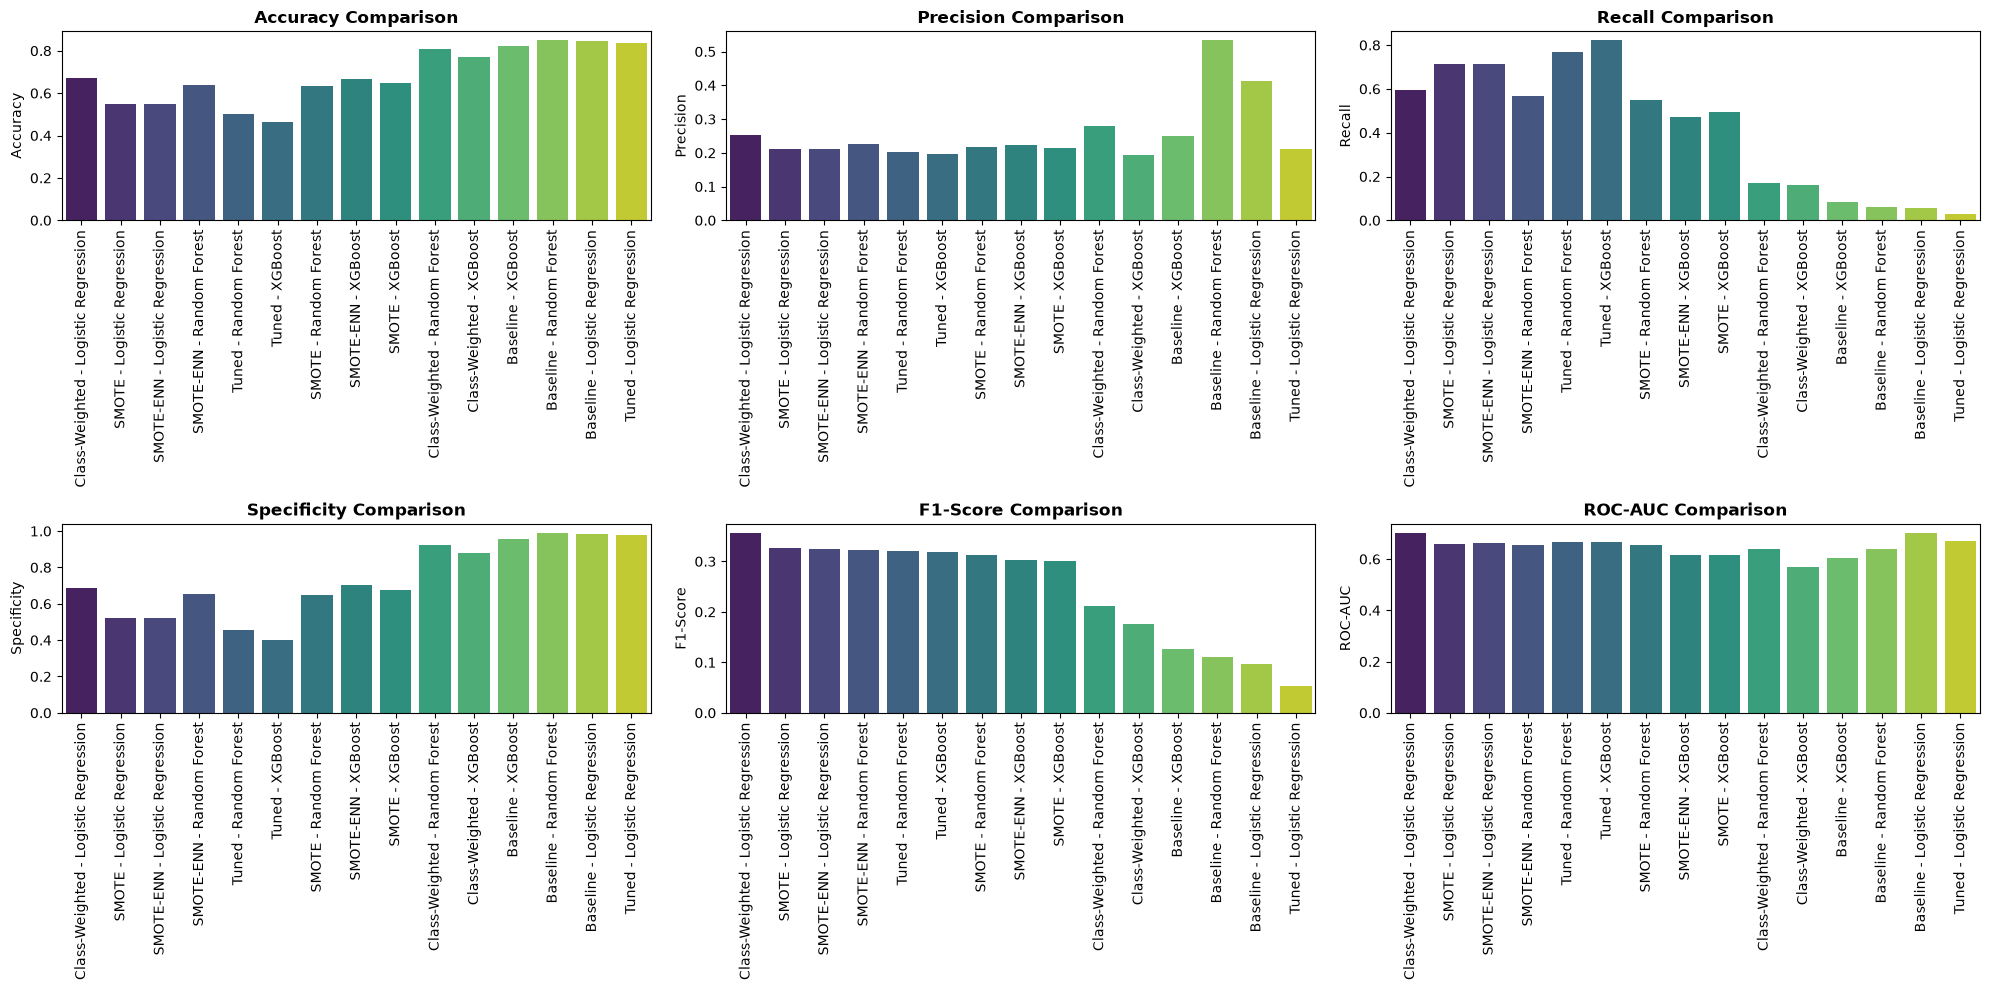

In [30]:
# Performance metrics to visualize
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1-Score",
    "ROC-AUC"
]

# Create bar charts for each evaluation metric
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

axes = axes.flatten()

for ax, metric in zip(axes, metrics):

    sns.barplot(
        data=comparison_table,
        x="Model",
        y=metric,
        hue="Model",
        palette="viridis",
        legend=False,
        ax=ax
    )

    ax.set_title(
        f"{metric} Comparison",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(
        axis="x",
        rotation=90
    )

plt.tight_layout()
plt.show()


The performance comparison charts reveal notable differences in the predictive performance of the fifteen machine learning models across the selected evaluation metrics. While the baseline models generally achieved higher Accuracy and Specificity, they recorded considerably lower Recall and F1-score values, indicating limited ability to correctly identify patients with coronary heart disease.

Among the imbalance-handling techniques, the class-weighted and resampling-based models demonstrated substantial improvements in Recall and F1-score. In particular, the Class-Weighted Logistic Regression model achieved the highest F1-score and ROC-AUC, suggesting a better balance between correctly identifying positive cases and minimizing false predictions. Similarly, the SMOTE and SMOTE-ENN Logistic Regression models produced competitive Recall values, demonstrating the effectiveness of oversampling techniques in improving minority class detection.

The tuned tree-based models, particularly Tuned Random Forest and Tuned XGBoost, achieved the highest Recall values, indicating superior sensitivity in detecting patients with coronary heart disease. Although these models exhibited lower Accuracy than some baseline models, their improved ability to identify positive cases makes them more suitable for medical diagnosis, where reducing false negatives is of greater clinical importance.

Overall, the visual comparison confirms that applying class weighting, SMOTE, SMOTE-ENN, and hyperparameter tuning improved the predictive performance of the developed models compared with their baseline counterparts. These findings demonstrate that addressing class imbalance leads to more reliable models for coronary heart disease prediction, particularly when evaluation is based on Recall, F1-score, and ROC-AUC rather than Accuracy alone.

### **Confusion Matrix Comparison**

The confusion matrix provides a detailed summary of the classification performance of each developed model by illustrating the number of correctly and incorrectly classified observations. Unlike summary performance metrics, confusion matrices provide insight into the distribution of true positives, true negatives, false positives, and false negatives. This visualization facilitates a direct comparison of the classification behaviour of the baseline, class-weighted, SMOTE, SMOTE-ENN, and tuned models.

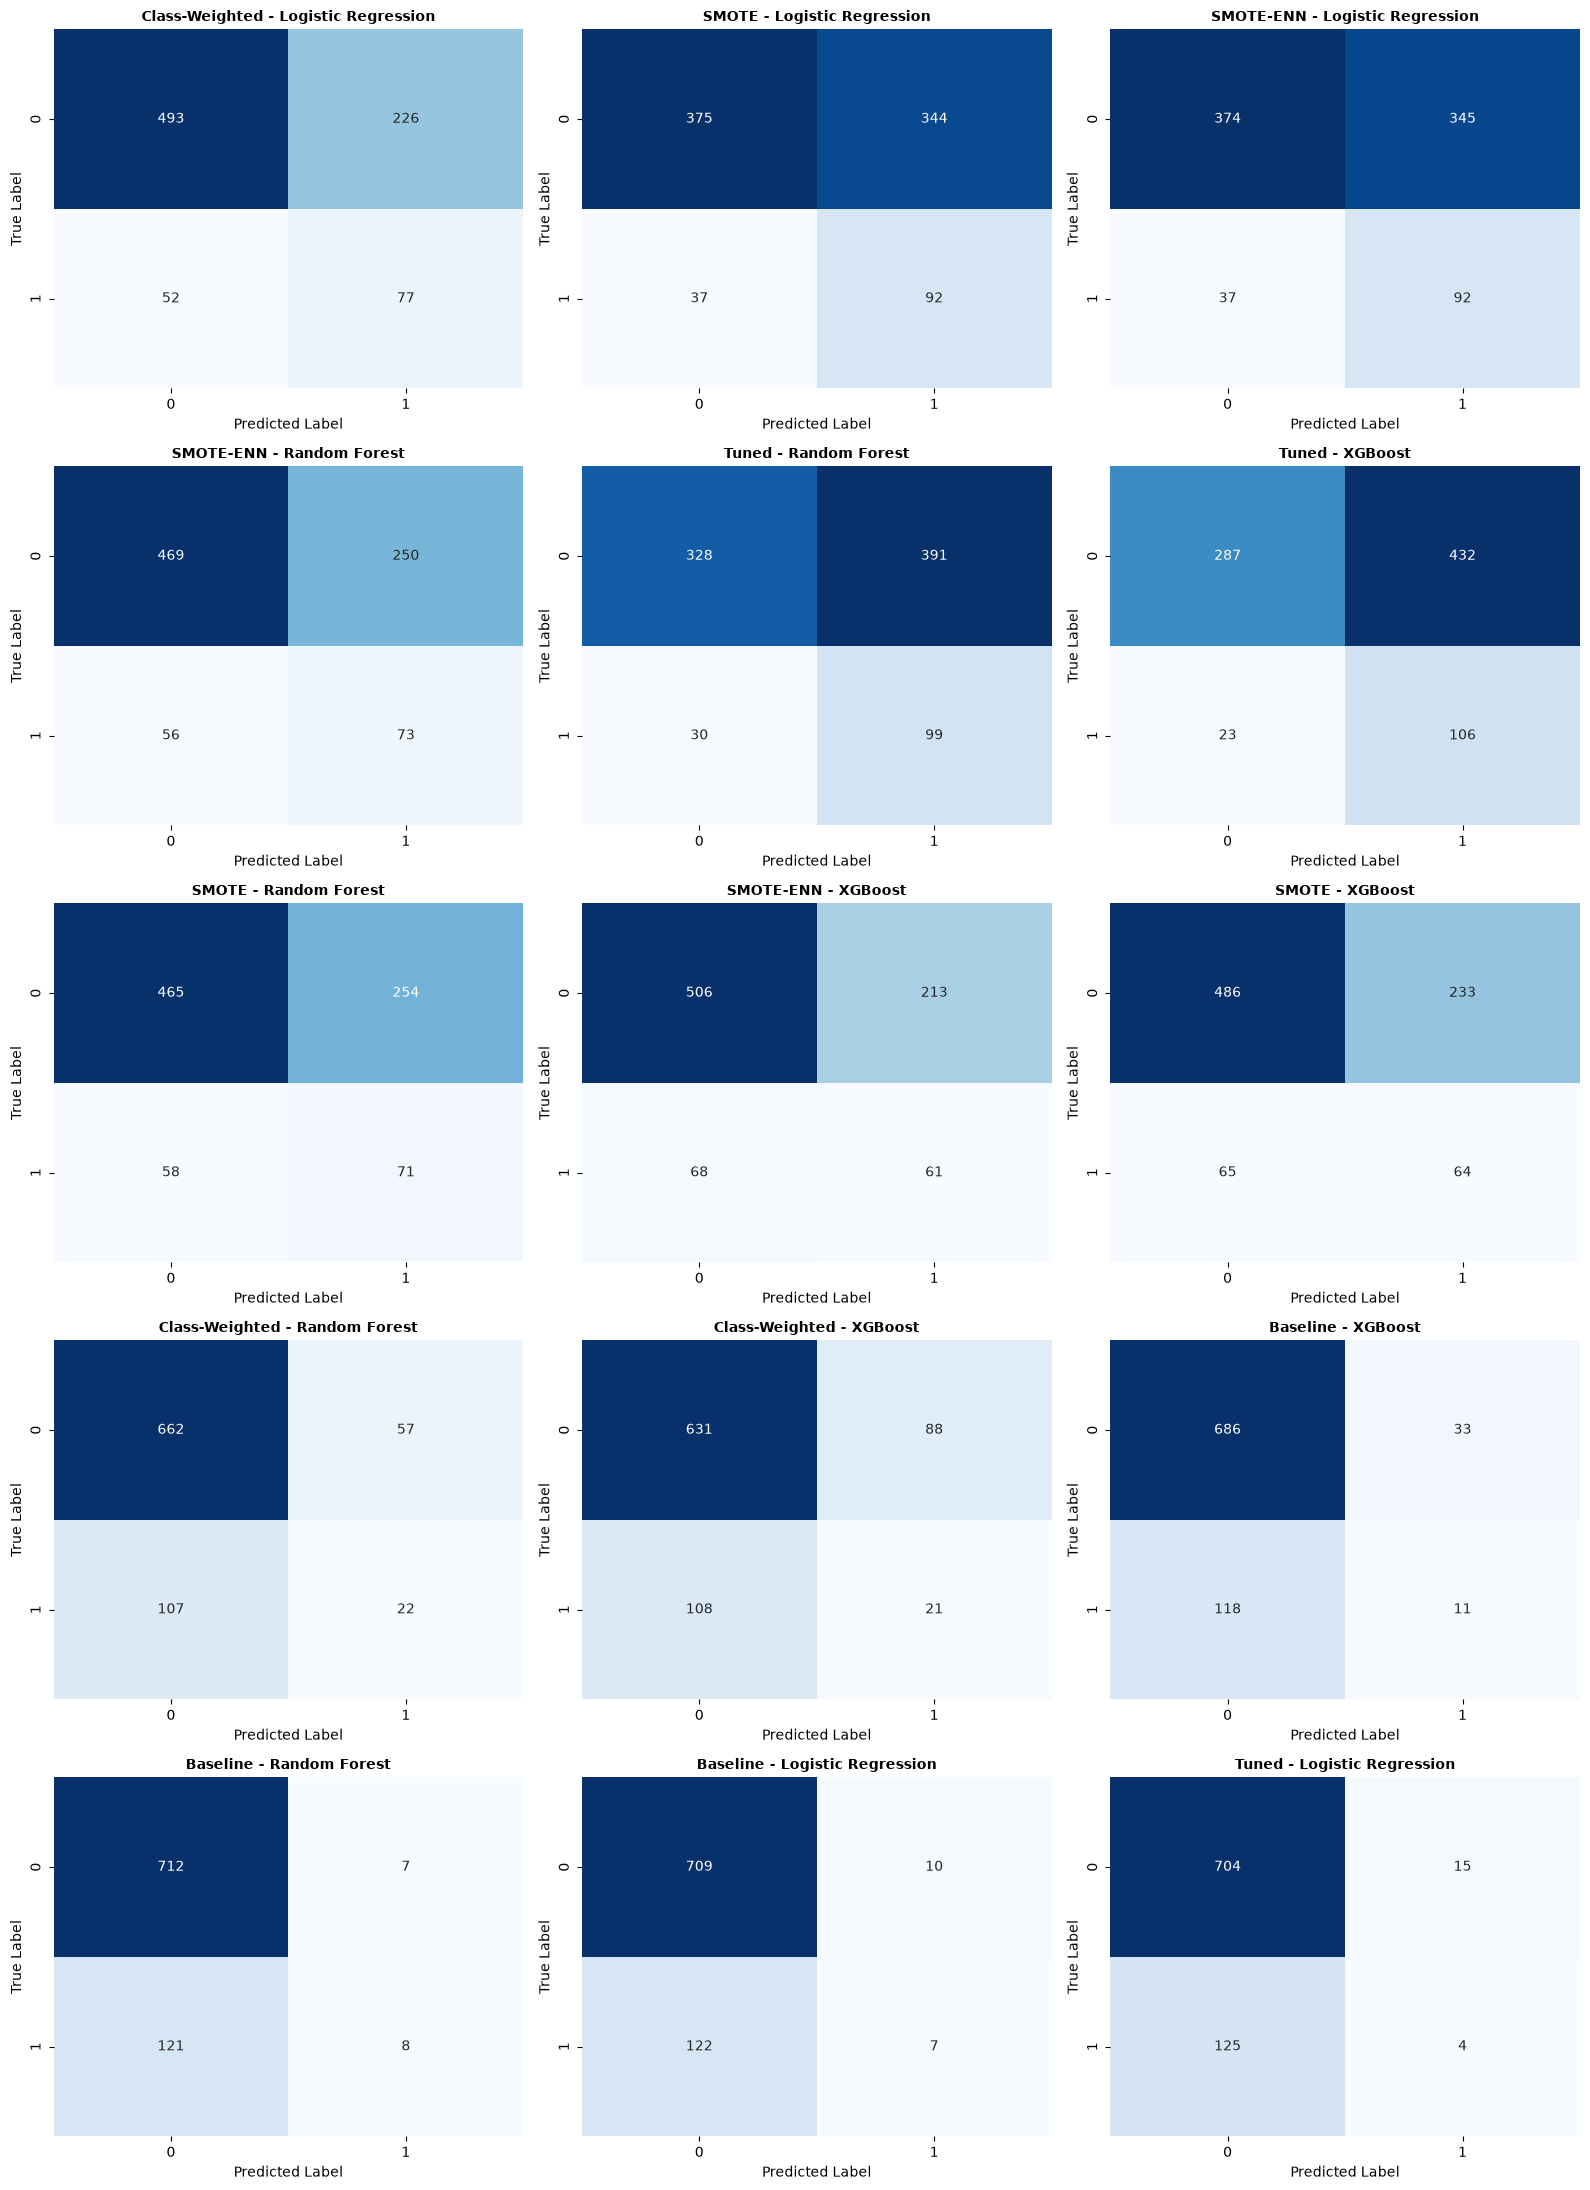

In [31]:
# Create confusion matrices for all models
fig, axes = plt.subplots(5, 3, figsize=(16, 22))

axes = axes.flatten()

for ax, model_name in zip(axes, comparison_table["Model"]):

    sns.heatmap(
        confusion_matrices[model_name],
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )

    ax.set_title(model_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()

plt.show()


The confusion matrices provide a detailed representation of the classification performance of the fifteen developed machine learning models by illustrating the distribution of true positives, true negatives, false positives, and false negatives. Unlike the summary performance metrics, these matrices provide a clearer understanding of how each model distinguishes between patients with and without coronary heart disease.

The baseline models correctly classified a large proportion of negative cases, as evidenced by their high numbers of true negatives. However, they identified relatively few positive cases, resulting in a large number of false negatives. For instance, the Baseline Logistic Regression model correctly identified only seven positive cases while misclassifying one hundred and twenty-two patients with coronary heart disease as negative. Similar patterns were observed for the Baseline Random Forest and Baseline XGBoost models, indicating that although these models achieved high overall accuracy, they were less effective in detecting patients with the disease.

The implementation of class weighting and resampling techniques substantially improved the detection of positive cases. The Class-Weighted Logistic Regression model increased the number of true positive predictions while reducing the number of false negatives compared with the baseline model. Likewise, the SMOTE and SMOTE-ENN Logistic Regression models correctly identified ninety-two positive cases while reducing the false negatives to thirty-seven, demonstrating the effectiveness of synthetic oversampling in improving minority class recognition.

Among the tree-based models, the tuned models exhibited the strongest performance in identifying patients with coronary heart disease. The Tuned Random Forest model correctly classified ninety-nine positive cases, whereas the Tuned XGBoost model achieved the highest number of true positives (106) and the fewest false negatives (23) among all evaluated models. These findings indicate that hyperparameter optimisation considerably enhanced the ability of the tree-based algorithms to detect patients with coronary heart disease.

Although several imbalance-handling techniques resulted in a slight increase in false positive predictions, this trade-off was accompanied by a substantial reduction in false negatives. In medical diagnosis, reducing false negatives is particularly important because failing to identify a patient with coronary heart disease may delay treatment and increase the risk of adverse clinical outcomes.

Overall, the confusion matrices confirm the findings obtained from the numerical performance metrics by demonstrating that class weighting, SMOTE, SMOTE-ENN, and hyperparameter tuning significantly improved the models' ability to identify patients with coronary heart disease. Among the evaluated models, the Tuned XGBoost and Tuned Random Forest models exhibited the strongest disease detection capability, while the Class-Weighted and SMOTE-based Logistic Regression models provided a more balanced classification performance than their baseline counterpart.

### **Receiver Operating Characteristic (ROC) Curve Comparison**

The Receiver Operating Characteristic (ROC) curve provides a graphical representation of the classification performance of each machine learning model across different decision thresholds. The ROC curve plots the True Positive Rate (Sensitivity) against the False Positive Rate (1 − Specificity), while the Area Under the Curve (ROC-AUC) measures the model's ability to distinguish between patients with and without coronary heart disease. A model with a larger ROC-AUC value demonstrates superior discriminatory performance and is generally considered more effective for binary classification.

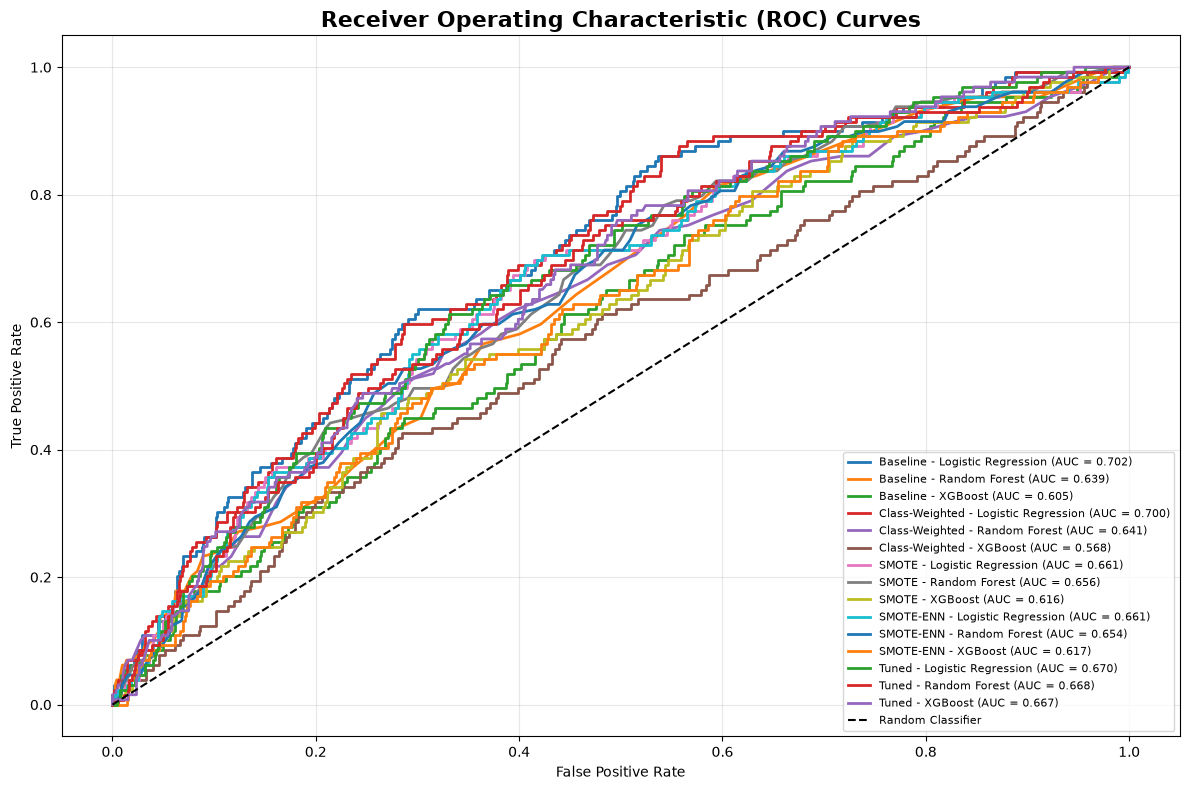

In [32]:
# Plot ROC curves for all evaluated models
plt.figure(figsize=(12, 8))

for model_name, roc_data in roc_curve_data.items():

    plt.plot(
        roc_data["FPR"],
        roc_data["TPR"],
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_score(y_test, prediction_results[model_name]['Probabilities']):.3f})"
    )

# Plot the random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curves",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The Receiver Operating Characteristic (ROC) curves provide a graphical comparison of the classification performance of the fifteen developed machine learning models across different decision thresholds. Models with curves closer to the upper-left corner of the plot exhibit better discrimination between patients with and without coronary heart disease, while the diagonal reference line represents the performance of a random classifier.

The ROC curve analysis indicates that the developed models achieved ROC-AUC values ranging from approximately 0.57 to 0.70, demonstrating varying levels of discriminatory performance. Among all evaluated models, the Baseline Logistic Regression model achieved the highest ROC-AUC value (0.702), closely followed by the Class-Weighted Logistic Regression model (0.700). These results indicate that the Logistic Regression models demonstrated the strongest overall ability to distinguish between positive and negative coronary heart disease cases.

The Tuned Logistic Regression, Tuned Random Forest, and Tuned XGBoost models also produced competitive ROC-AUC values of 0.670, 0.668, and 0.667, respectively. These findings suggest that hyperparameter optimisation enhanced the discriminatory performance of the tree-based algorithms, resulting in improved classification capability compared with several of their baseline and resampling counterparts.

The Random Forest models generally achieved moderate ROC-AUC values, ranging from 0.639 for the Baseline Random Forest model to 0.668 for the Tuned Random Forest model, indicating that both class balancing and hyperparameter tuning contributed to improved model discrimination. Similarly, the XGBoost models exhibited ROC-AUC values between 0.568 and 0.667, with the Tuned XGBoost model demonstrating the best discriminatory performance within the XGBoost family.

Overall, the ROC curves demonstrate that all evaluated models performed better than random classification, as evidenced by their ROC curves lying above the reference diagonal. Although the differences in ROC-AUC among several models were relatively small, the application of class weighting, resampling techniques, and hyperparameter tuning generally improved the models' ability to discriminate between patients with and without coronary heart disease. These findings complement the confusion matrix and performance metric analyses, providing further evidence of the effectiveness of the developed machine learning models for coronary heart disease prediction.

### **Feature Importance Analysis**

Feature importance analysis was conducted to identify the variables that contributed most to the prediction of coronary heart disease. Tree-based machine learning algorithms estimate the relative importance of each predictor by measuring its contribution to reducing classification error during model construction. This analysis provides insight into the clinical variables that most strongly influenced the prediction outcomes and enhances the interpretability of the developed models.

In [33]:
# Select tree-based models for feature importance analysis
feature_models = {
    "Baseline Random Forest": models["Baseline - Random Forest"],
    "Class-Weighted Random Forest": models["Class-Weighted - Random Forest"],
    "SMOTE Random Forest": models["SMOTE - Random Forest"],
    "SMOTE-ENN Random Forest": models["SMOTE-ENN - Random Forest"],
    "Tuned Random Forest": models["Tuned - Random Forest"],
    
    "Baseline XGBoost": models["Baseline - XGBoost"],
    "Class-Weighted XGBoost": models["Class-Weighted - XGBoost"],
    "SMOTE XGBoost": models["SMOTE - XGBoost"],
    "SMOTE-ENN XGBoost": models["SMOTE-ENN - XGBoost"],
    "Tuned XGBoost": models["Tuned - XGBoost"]
}

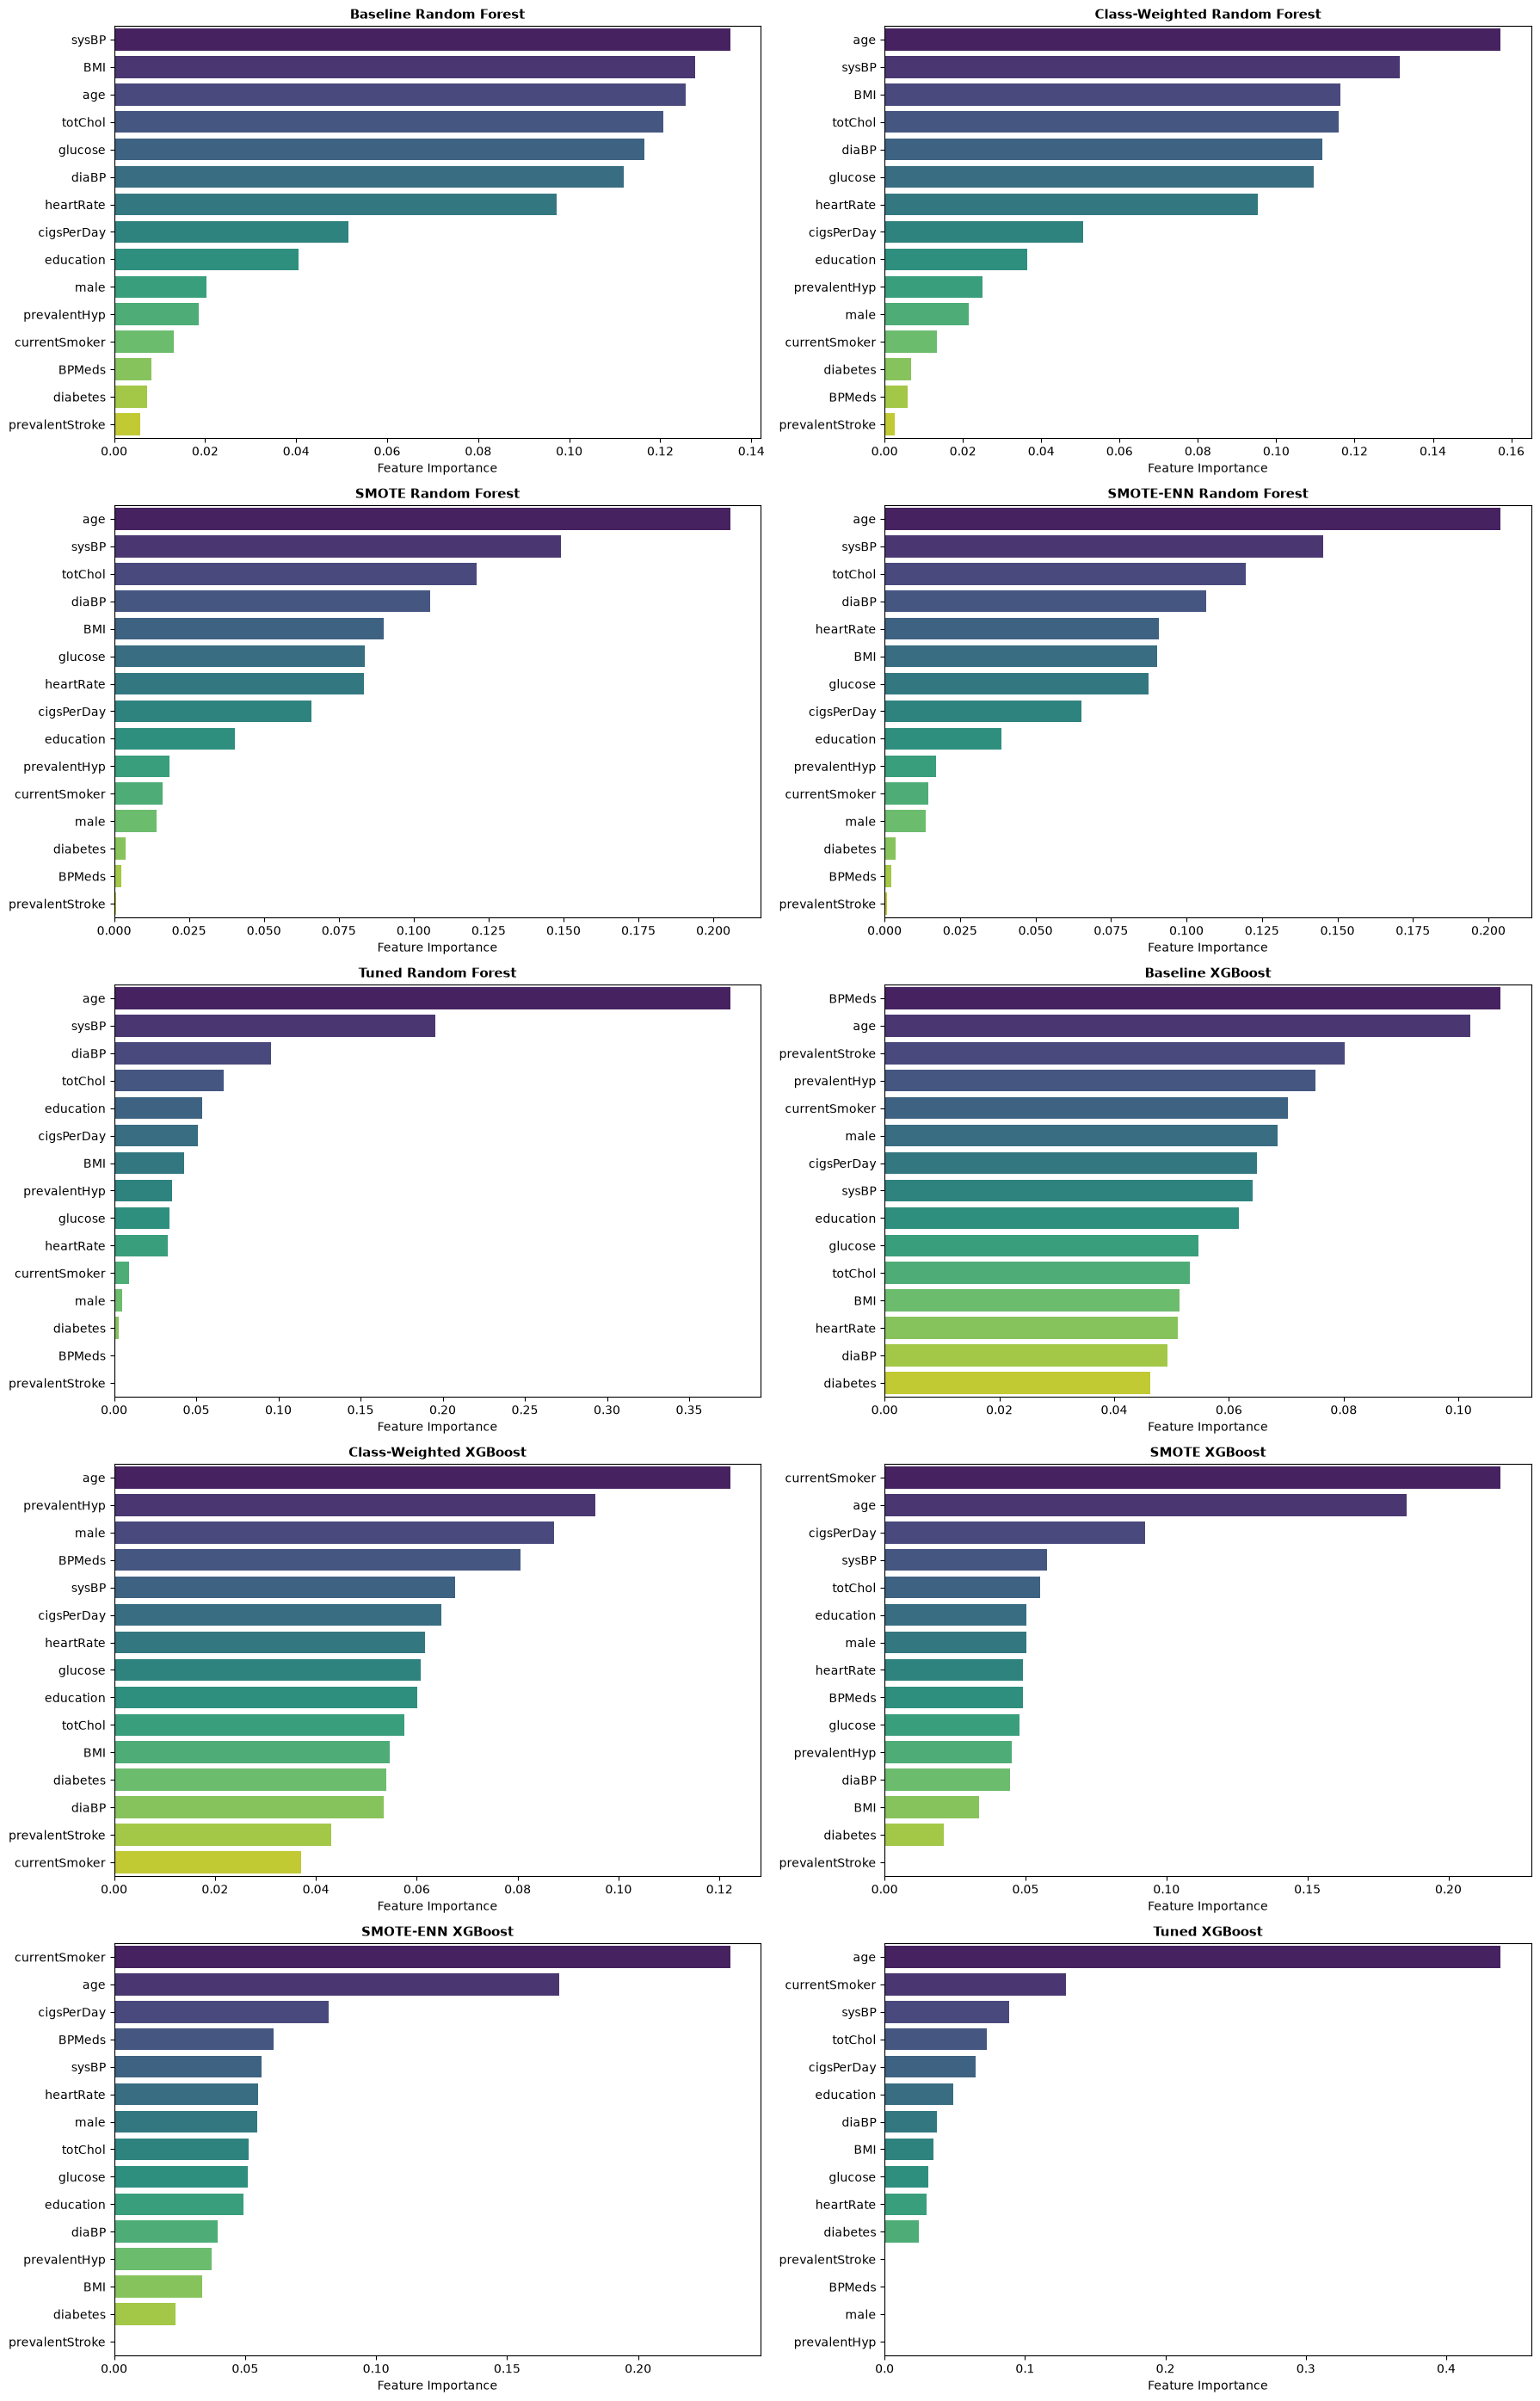

In [35]:
# Extract feature importance from a model or pipeline
def get_feature_importance(model):

    # Model has feature importance directly
    if hasattr(model, "feature_importances_"):
        return model.feature_importances_

    # Model is stored inside a pipeline
    if hasattr(model, "named_steps"):

        # Search the pipeline steps for the fitted classifier
        for step in reversed(model.named_steps.values()):
            if hasattr(step, "feature_importances_"):
                return step.feature_importances_

    raise AttributeError(
        "Feature importance could not be extracted from this model."
    )


# Plot feature importance for all tree-based models
fig, axes = plt.subplots(5, 2, figsize=(18, 28))

axes = axes.flatten()

for ax, (model_name, model) in zip(
    axes,
    feature_models.items()
):

    # Extract feature importance
    importance_values = get_feature_importance(model)

    # Create and sort feature importance values
    importance = pd.Series(
        importance_values,
        index=X_test.columns
    ).sort_values(ascending=False)

    # Plot feature importance
    sns.barplot(
        x=importance.values,
        y=importance.index,
        hue=importance.index,
        palette="viridis",
        legend=False,
        ax=ax
    )

    ax.set_title(
        model_name,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Feature Importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

The feature importance plots illustrate the relative contribution of each predictor variable to the classification of coronary heart disease across the Random Forest and XGBoost models developed using the different modelling strategies. Variables with higher importance scores contributed more substantially to the prediction process, whereas variables with lower scores had a comparatively smaller influence on the classification outcomes.

The Random Forest models consistently identified age and systolic blood pressure (sysBP) as two of the most influential predictors of coronary heart disease. Other variables, including body mass index (BMI), total cholesterol (totChol), diastolic blood pressure (diaBP), glucose, and heart rate, also contributed considerably to model predictions. Although the relative importance of these variables varied across the baseline, class-weighted, SMOTE, SMOTE-ENN, and tuned models, age remained the dominant predictor in most of the Random Forest models, particularly after the application of resampling techniques and hyperparameter optimisation.

Similarly, the XGBoost models identified age as one of the most influential predictors in the majority of modelling strategies. However, the importance assigned to other variables differed across the various XGBoost models. Variables such as current smoking status (currentSmoker), prevalent hypertension (prevalentHyp), systolic blood pressure (sysBP), cigarettes smoked per day (cigsPerDay), and total cholesterol (totChol) demonstrated increased importance in several of the resampling-based and tuned models. This variation suggests that XGBoost adjusted the relative contribution of predictor variables as different imbalance-handling techniques and optimisation strategies were applied during model development.

The tuned Random Forest and Tuned XGBoost models exhibited a more concentrated distribution of feature importance, with a smaller number of variables contributing more strongly to the prediction process. This indicates that hyperparameter optimisation enabled the models to place greater emphasis on the most informative clinical predictors while reducing the influence of less important variables.

Overall, the feature importance analysis demonstrates that demographic characteristics, blood pressure measurements, anthropometric indices, biochemical measurements, and smoking-related variables were among the most influential predictors of coronary heart disease across the developed tree-based models. The consistency of these important predictors across multiple modelling strategies suggests that they play a significant role in distinguishing between patients with and without coronary heart disease, thereby enhancing the interpretability and clinical relevance of the developed machine learning models.

## **Logistic Regression Coefficient Analysis**

Unlike tree-based algorithms, Logistic Regression estimates the influence of predictor variables through regression coefficients. The magnitude of each coefficient reflects the strength of the predictor, whereas the sign indicates whether the variable increases or decreases the likelihood of coronary heart disease. Positive coefficients indicate variables associated with a higher probability of disease occurrence, while negative coefficients indicate variables associated with a lower probability. This analysis improves the interpretability of the Logistic Regression models by identifying the clinical variables that contribute most to prediction.

In [37]:
# Logistic Regression models
lr_models = {
    "Baseline Logistic Regression":
        models["Baseline - Logistic Regression"],

    "Class-Weighted Logistic Regression":
        models["Class-Weighted - Logistic Regression"],

    "SMOTE Logistic Regression":
        models["SMOTE - Logistic Regression"],

    "SMOTE-ENN Logistic Regression":
        models["SMOTE-ENN - Logistic Regression"],

    "Tuned Logistic Regression":
        models["Tuned - Logistic Regression"]
}

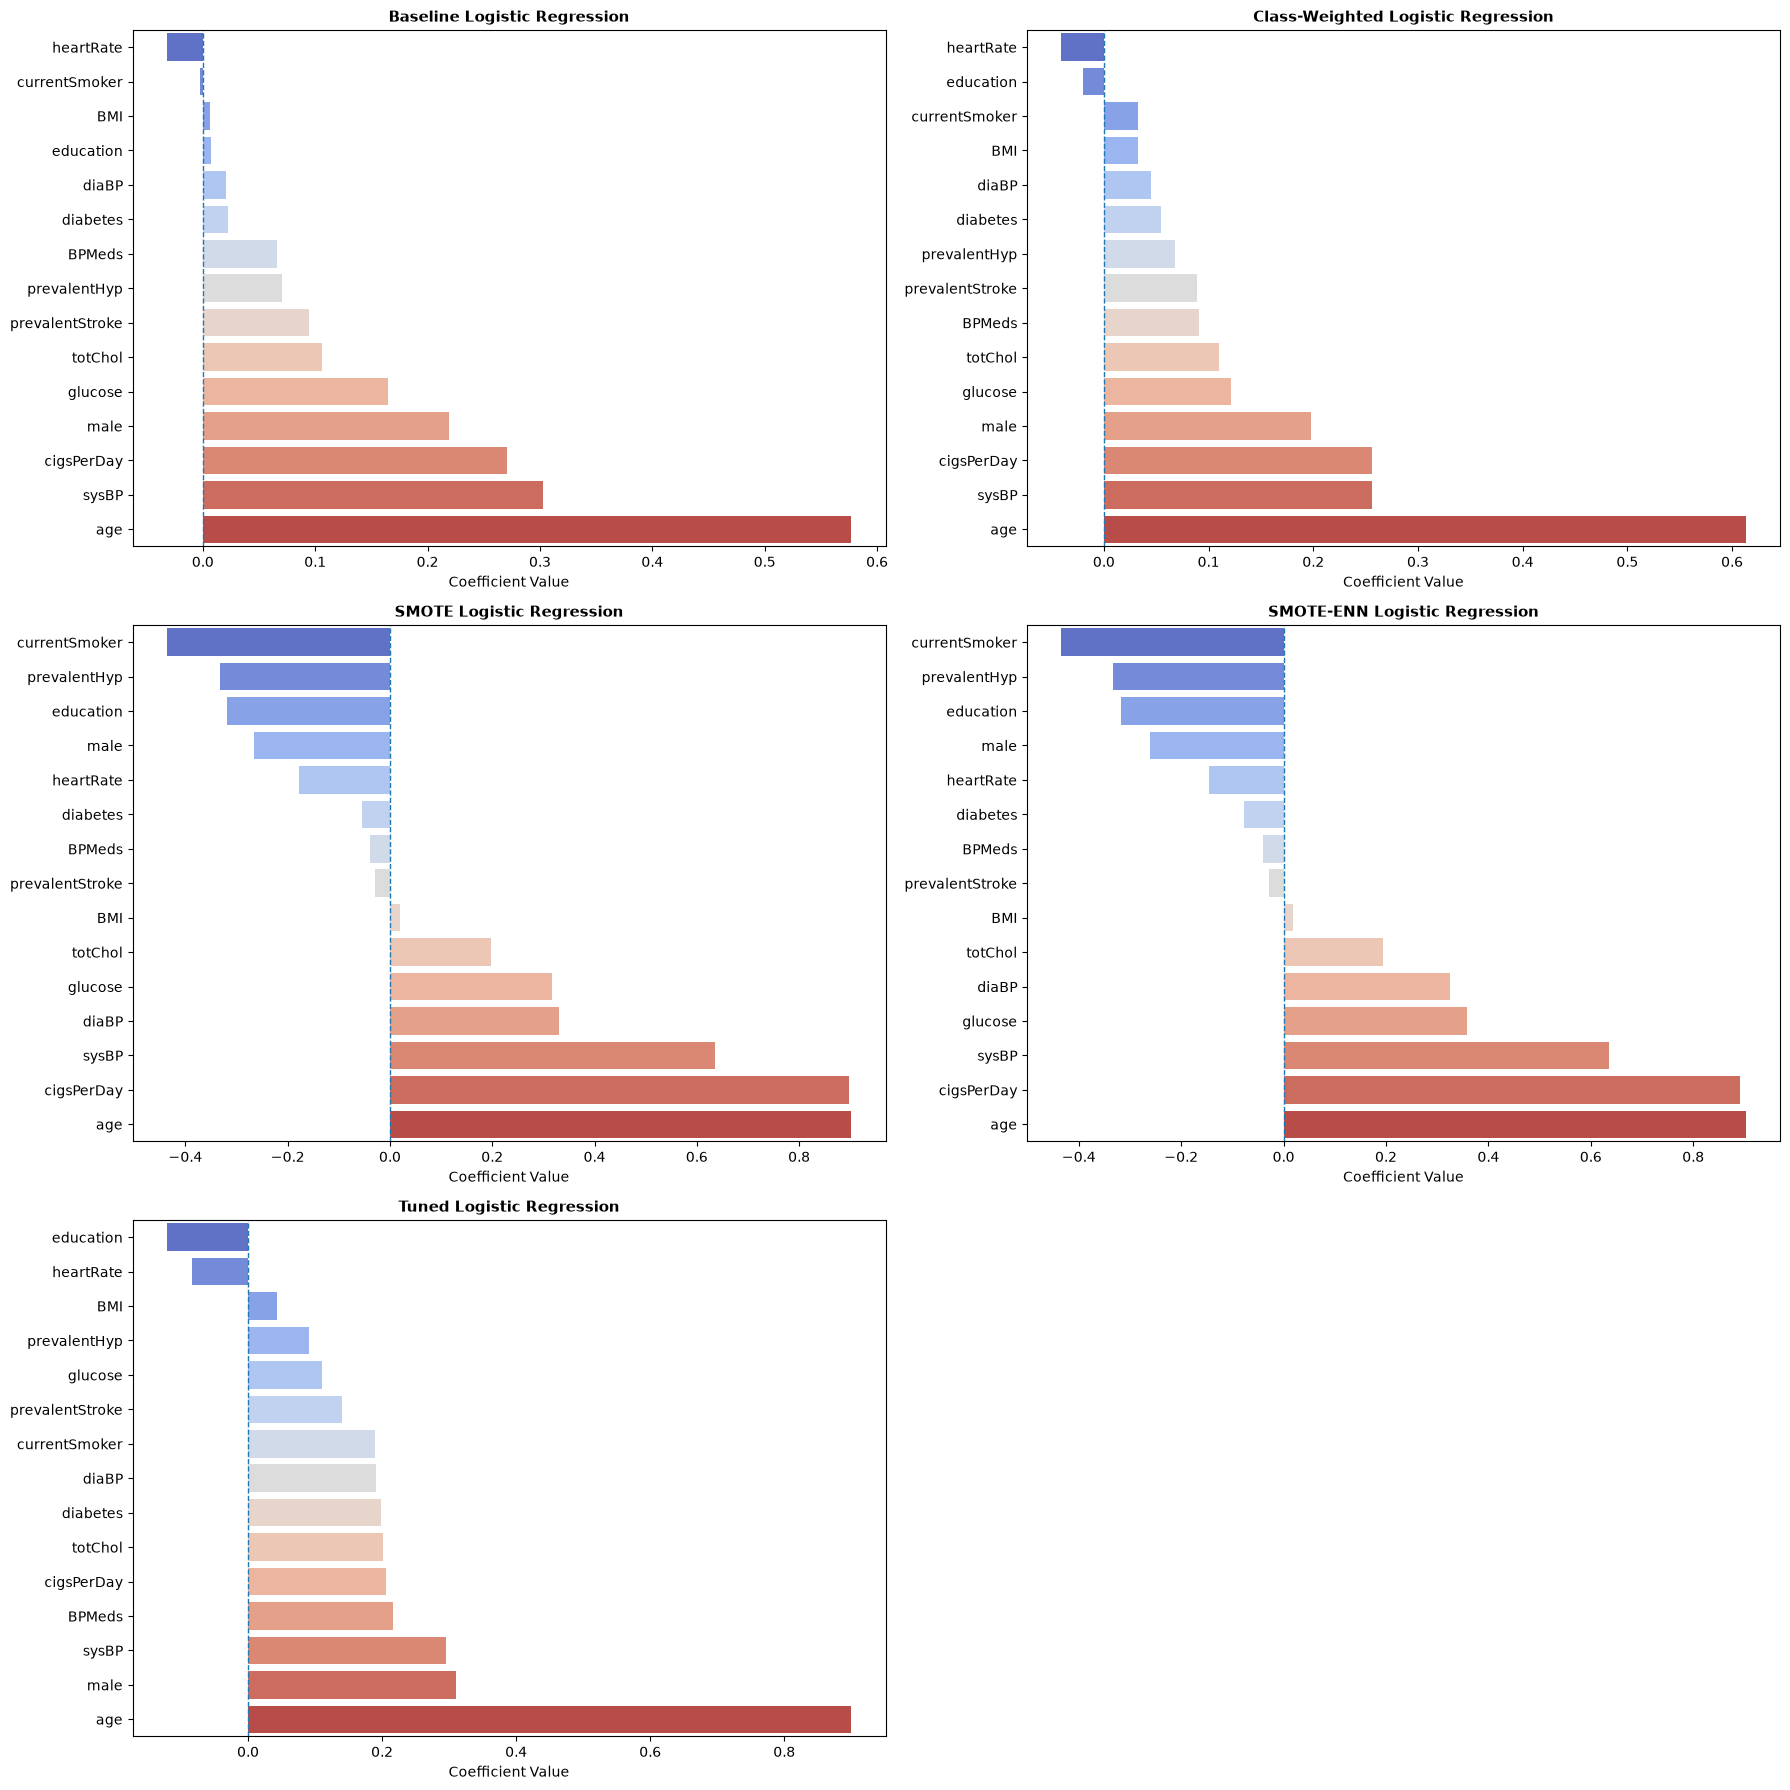

In [39]:
# Extract coefficients from a Logistic Regression model or pipeline
def get_logistic_coefficients(model):

    # Direct Logistic Regression model
    if hasattr(model, "coef_"):
        return model.coef_[0]

    # Logistic Regression model stored inside a pipeline
    if hasattr(model, "named_steps"):

        for step in reversed(model.named_steps.values()):
            if hasattr(step, "coef_"):
                return step.coef_[0]

    raise AttributeError(
        "Logistic Regression coefficients could not be extracted."
    )


# Plot Logistic Regression coefficients
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

axes = axes.flatten()

for ax, (model_name, model) in zip(
    axes,
    lr_models.items()
):

    # Extract model coefficients
    coefficient_values = get_logistic_coefficients(model)

    # Create and sort coefficient values
    coefficients = pd.Series(
        coefficient_values,
        index=X_test.columns
    ).sort_values()

    # Plot coefficients
    sns.barplot(
        x=coefficients.values,
        y=coefficients.index,
        hue=coefficients.index,
        palette="coolwarm",
        legend=False,
        ax=ax
    )

    # Add a vertical reference line at zero
    ax.axvline(
        x=0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        model_name,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Coefficient Value")
    ax.set_ylabel("")

# Remove unused subplot
for unused_ax in axes[len(lr_models):]:
    fig.delaxes(unused_ax)

plt.tight_layout()
plt.show()


The Logistic Regression coefficient plots illustrate the direction and magnitude of the contribution of each predictor variable to the classification of coronary heart disease across the five Logistic Regression models. Positive coefficients indicate variables associated with an increased likelihood of coronary heart disease, whereas negative coefficients indicate variables associated with a reduced likelihood. Variables with larger absolute coefficient values exert a greater influence on the prediction outcome.

Across all five models, age consistently exhibited the largest positive coefficient, indicating that increasing age was the strongest predictor of coronary heart disease. Systolic blood pressure (sysBP) and cigarettes smoked per day (cigsPerDay) also demonstrated relatively large positive coefficients in most models, suggesting that elevated blood pressure and smoking behaviour were important contributors to disease prediction. Other variables, including glucose, total cholesterol (totChol), diabetes, body mass index (BMI), and prevalent stroke, also contributed positively, although with comparatively smaller effects.

The application of class weighting and resampling techniques altered both the magnitude and direction of several predictor coefficients. In the SMOTE and SMOTE-ENN Logistic Regression models, variables such as current smoking status (currentSmoker), prevalent hypertension (prevalentHyp), education, and heart rate exhibited larger negative coefficients compared with the baseline model. These changes indicate that balancing the minority class influenced the relationship learned between the predictor variables and the target outcome, allowing the models to better distinguish patients with coronary heart disease.

The Tuned Logistic Regression model retained age as the most influential positive predictor while exhibiting a more balanced distribution of coefficient magnitudes across the remaining variables. This suggests that hyperparameter optimisation refined the contribution of individual predictors without substantially altering the overall relationships identified by the Logistic Regression algorithm.

Overall, the coefficient analysis demonstrates that demographic characteristics, blood pressure measurements, smoking-related variables, and metabolic risk factors were the principal determinants of coronary heart disease prediction in the Logistic Regression models. Furthermore, the observed changes in coefficient magnitude across the baseline, class-weighted, SMOTE, SMOTE-ENN, and tuned models confirm that imbalance-handling techniques and hyperparameter optimisation influenced how the Logistic Regression models learned from the training data while preserving the importance of the key clinical predictors.

### **Overall Model Comparison and Selection**

The comparative evaluation of the fifteen machine learning models demonstrates that the application of class weighting, resampling techniques, and hyperparameter optimisation substantially influenced predictive performance. Each modelling strategy exhibited distinct strengths across the selected evaluation metrics, highlighting the importance of considering multiple performance measures when selecting an appropriate model for coronary heart disease prediction.

Although the baseline models achieved the highest Accuracy and Specificity, they consistently recorded low Recall values, indicating poor detection of patients with coronary heart disease. This limitation reduces their suitability for clinical applications where failing to identify diseased patients may have serious consequences.

The class-weighted and resampling-based models achieved considerable improvements in Recall and F1-score, demonstrating that addressing class imbalance enhanced the ability of the models to identify positive coronary heart disease cases. Similarly, the tuned models further improved predictive performance through hyperparameter optimisation, resulting in better discrimination between the two outcome classes.

Considering the combined performance across Accuracy, Precision, Recall, F1-score, ROC-AUC, confusion matrices, and model interpretability, the developed imbalance-handling models demonstrated superior overall performance compared with their baseline counterparts. These findings suggest that incorporating class balancing and model optimisation techniques is essential for developing reliable machine learning models for coronary heart disease prediction.

### **Conclusion**

This notebook presented a comprehensive comparative evaluation of fifteen machine learning models developed for coronary heart disease prediction using baseline, class-weighted, SMOTE, SMOTE-ENN, and tuned modelling strategies. Model performance was assessed using Accuracy, Precision, Recall, Specificity, F1-score, ROC-AUC, confusion matrices, ROC curves, feature importance analysis, and Logistic Regression coefficient analysis.

The results demonstrated that models developed using imbalance-handling techniques consistently outperformed their baseline counterparts in detecting patients with coronary heart disease. While the baseline models achieved high Accuracy, they exhibited poor Recall, indicating limited capability to identify positive disease cases. Conversely, the class-weighted, SMOTE, SMOTE-ENN, and tuned models achieved a more balanced trade-off between sensitivity and overall predictive performance.

The feature importance and coefficient analyses further improved model interpretability by identifying the clinical variables that contributed most strongly to coronary heart disease prediction. Age, systolic blood pressure, smoking-related variables, blood glucose, and cholesterol consistently emerged as important predictors across the developed models.

Overall, the findings demonstrate that addressing class imbalance and applying hyperparameter optimisation improve the robustness, reliability, and clinical applicability of machine learning models for coronary heart disease prediction. The results of this comparative analysis provide a strong foundation for selecting appropriate predictive models to support early detection and decision-making in clinical practice.

**Next Phase:** Model Explainability